In [28]:
import pandas as pd
import re
from pathlib import Path
import numpy as np

In [29]:
RAW_FILE = Path('farsnet_facts.tsv')
CLEAN_FILE = Path('farsnet_facts_cleaned.parquet')

## 1- Load And Normalizing Farsnet Facts File

In [30]:
ARABIC_CHARS = re.compile(r"[\u064B-\u065F]")
def normalise(text: str) -> str:
    if not isinstance(text, str):
        return text
    text = ARABIC_CHARS.sub("", text)
    text = text.replace("ي", "ی").replace("ك", "ک")
    return text.strip()

print("Reading raw triples …")
df = pd.read_csv(
        RAW_FILE,
        sep="\t",
        names=["sid", "subject_words", "relation", "tid"],
        dtype=str,
        keep_default_na=False,
        quoting=3
)

print("Normalising text …")
for col in ("subject_words", "relation"):
    df[col] = df[col].map(normalise)

df = df.drop_duplicates(subset=["sid", "relation", "tid"]).reset_index(drop=True)
print("rows after de-dup:", len(df))

#Save the file
df.to_parquet(CLEAN_FILE, index=False)
print(f"Clean DataFrame written to {CLEAN_FILE}")
print(df.head())

Reading raw triples …
Normalising text …
rows after de-dup: 199591
Clean DataFrame written to farsnet_facts_cleaned.parquet
        sid             subject_words      relation             tid
0  SynsetID               SynsetWords  RelationType  TargetSynsetID
1         1  بیرونی|خارجی|روکار|برونی       Antonym               2
2         1  بیرونی|خارجی|روکار|برونی    Related-to           29920
3         1  بیرونی|خارجی|روکار|برونی    Related-to           27736
4         1  بیرونی|خارجی|روکار|برونی    Related-to           35438


## 2- Triple Vectorization
#### For each cleaned row, we will produce sid | subject_words | relation | tid. We will have a 301-dimensional vector.

In [31]:
from gensim.models import KeyedVectors
import tqdm
import pyarrow as pa,pyarrow.parquet as pq
# File paths
FT_PATH      = "cc.fa.300.vec.gz"   # <-- update if different
OUT_FILE_VEC = "farsnet_vectors.parquet"

In [32]:
# First load ft for efficiency (We just run it once)
ft = KeyedVectors.load_word2vec_format("cc.fa.300.vec.gz", binary=False)
ft.save("cc.fa.300.kv")

KeyboardInterrupt: 

In [ ]:
ft = KeyedVectors.load("cc.fa.300.kv")

In [ ]:
df = pd.read_parquet(CLEAN_FILE, columns=["sid","subject_words","relation",'tid'])

rel2id = {rel:i for i,rel in enumerate(sorted(df["relation"].unique()))}
df["rel_id"] = df["relation"].map(rel2id).astype("uint16")

def mean_ft(tokens):
    vecs = [ft[w] for w in tokens.split() if w in ft]
    return np.mean(vecs, axis=0) if vecs else np.zeros(300, dtype="float32")

print("Vectorising …")
subs = [mean_ft(s) for s in tqdm.tqdm(df["subject_words"], total=len(df))]
sub_mat = np.vstack(subs).astype("float32")

rel_vec = df["rel_id"].to_numpy(dtype="uint16")[:,None]
feat_mat = np.hstack([rel_vec.astype("float32"), sub_mat])

rel_vec_f32 = df["rel_id"].to_numpy(dtype=np.float32)[:, None]

feat_mat = np.hstack([rel_vec_f32, sub_mat])

table = pa.table(
    {
        "sid":    pa.array(df["sid"]),
        "tid":    pa.array(df["tid"]),
        "rel_id": pa.array(df["rel_id"], type=pa.uint16()),
        "vec":    pa.FixedSizeListArray.from_arrays(feat_mat.ravel(), 301)
    })
pq.write_table(table, OUT_FILE_VEC)
print("Saved vectors to:", OUT_FILE_VEC)

## 3- Clustering
#### Clusters the 301-d feature vectors
#### Then computes cluster_rank = average number of distinct objects (tids) per (sid, rel) pair inside each cluster
#### Writes an enriched Parquet file

In [ ]:
# set the paths and parameters
VEC_FILE   = r"farsnet_vectors.parquet"
OUT_FILE   = r"farsnet_vectors_clustered.parquet"
N_CLUSTERS = 20
RANDOM_SEED = 42

In [ ]:
from sklearn.cluster import MiniBatchKMeans


In [ ]:
# load vectors
table = pq.read_table(VEC_FILE)
df    = table.to_pandas()
mat   = np.vstack(df["vec"].to_numpy())  # (N, 301) float32

# clustering
print(f"Clustering with k={N_CLUSTERS} …")
kmeans = MiniBatchKMeans(n_clusters=N_CLUSTERS,
                         random_state=RANDOM_SEED,
                         batch_size=10_000,
                         n_init="auto")
df["cluster"] = kmeans.fit_predict(mat).astype("uint8")

# compute cluster ranks
pair_size = df.groupby(["sid", "rel_id"])["tid"].nunique().rename("obj_cnt")
df = df.join(pair_size, on=["sid", "rel_id"])

# average within each cluster
rank = df.groupby("cluster")["obj_cnt"].mean().rename("cluster_rank")
df   = df.join(rank, on="cluster")
df.drop(columns="obj_cnt", inplace=True)
df["cluster_rank"] = df["cluster_rank"].astype("float32")

# save the results
cols = ["sid", "tid", "rel_id", "cluster", "cluster_rank", "vec"]
pq.write_table(pa.Table.from_pandas(df[cols]), OUT_FILE)
print("✓ Saved to: ", OUT_FILE)

## 4- Question Formats Assignment
#### Load the file produced in Step 3
#### Map cluster rank to the question format
#### Write a new Parquet file for step 5

In [ ]:
CLUSTERED_FILE = r"farsnet_vectors_clustered.parquet"
OUT_FILE_QFMT  = r"farsnet_vectors_qfmt.parquet"

In [ ]:
df = pd.read_parquet(CLUSTERED_FILE)
def choose_format(rank: float) -> str:
    if rank <= 1.5:
        return "true_false"
    elif rank <= 5:
        return "short_list"
    elif rank <= 10:
        return "select_all_mcq"
    else:
        return "hybrid_mcq"

df["q_format"] = df["cluster_rank"].apply(choose_format).astype("category")

پcols = ["sid", "tid", "rel_id", "cluster", "cluster_rank", "q_format", "vec"]
df[cols].to_parquet(OUT_FILE_QFMT, index=False)
print(" Question formats assigned to:", OUT_FILE_QFMT)


## 5- Template Library Creation
#### Loads the file from Step 4
#### Builds lightweight lookup tables:
#####   . sid → subject_words and tid → object_words
#####   . rel_id → relation_text
#### Implements four reusable renderers – one per q_format
#### Return a new Dataframe with one row per (sid,rel) containing:
#####   . the question string
#####   . the list of gold objects (for scoring)
#####   . a list of distractors if the format needs them

In [ ]:
VEC_QFMT_FILE = r"farsnet_vectors_qfmt.parquet"
CLEAN_FILE    = r"farsnet_facts_cleaned.parquet"
PROMPTS_RAW = r'prompts_raw.parquet'
MAX_ENUM      = 5
NEG_RATIO     = (2,1)

In [ ]:
import random,json
from collections import defaultdict
import re
from pathlib import Path


In [ ]:
TOKEN_RGX = re.compile(r"[ \t\u200c|\\/()\[\]{}]+")
PUNCT_RGX = re.compile(r"^[\W_]+|[\W_]+$")

clean      = pd.read_parquet(CLEAN_FILE,
                              columns=["sid","subject_words","relation","tid"])
sid2text   = clean.drop_duplicates("sid").set_index("sid")["subject_words"].to_dict()
tid2text   = clean.drop_duplicates("tid").set_index("tid")["subject_words"].to_dict()
rel2id = {r:i for i,r in enumerate(sorted(clean["relation"].unique()))}
id2rel = {v:k for k,v in rel2id.items()}


In [ ]:
df_fmt = pd.read_parquet(VEC_QFMT_FILE)



REL_MAP_FILE = "relation_text_map.json"
if Path(REL_MAP_FILE).is_file():
    rel_phrase = json.load(open(REL_MAP_FILE, encoding="utf-8"))
else:
    rel_phrase = defaultdict(str)

relid2txt = {
    rid: rel_phrase.get(rel, rel)
    for rid, rel in id2rel.items()
}

def get_rel_txt(rid: int) -> str:
    return relid2txt.get(rid, id2rel.get(rid, str(rid)))


def pretty_obj(txt: str) -> str:
    first = txt.split("|")[0]
    return PUNCT_RGX.sub("", first).strip()

slice_df = (
    df_fmt.groupby(["sid", "rel_id", "q_format"], observed=True)
          .agg(objs=("tid", list), cluster_rank=("cluster_rank", "first"))
          .reset_index()
)



MAX_ENUM = 4
def true_false(subj, rel_id, obj_texts, negs=None):
    rel_txt = get_rel_txt(rel_id)

    is_true = random.random() < 0.5
    if is_true:
        obj_txt = obj_texts[0]
        gold    = ["True"]
    else:
        cand_ids = [
            t for t in tid2text
            if t not in obj_texts
        ]
        fake_tid = random.choice(cand_ids) if cand_ids else None
        obj_txt  = pretty_obj(tid2text.get(fake_tid, "…"))
        gold     = ["False"]

    prompt = f"«آیا «{subj}» {rel_txt} «{obj_txt}» است؟ فقط «True» یا «False» پاسخ دهید.»"
    return prompt, gold


def short_list(subj, rel_id, obj_texts):
    rel_txt = get_rel_txt(rel_id)
    n = min(len(obj_texts), MAX_ENUM)
    return f"«{n} مورد از «{rel_txt}» برای «{subj}» را نام ببرید.»", obj_texts[:n]

def select_all_mcq(subj, rel_id, obj_texts, negs):
    rel_txt = get_rel_txt(rel_id)
    items   = obj_texts + negs
    random.shuffle(items)
    opts = "  ".join(f"[ ] {x}" for x in items)
    return f"«کدام گزینه‌ها {rel_txt} «{subj}» هستند؟»\n{opts}", obj_texts

def hybrid_mcq(subj, rel_id, obj_texts, negs):
    rel_txt = get_rel_txt(rel_id)

    cnt_prompt = f"«چند {rel_txt} برای «{subj}» تعریف شده است؟»"
    items = obj_texts + negs
    random.shuffle(items)
    opts = "  ".join(f"[ ] {x}" for x in items)
    sel_prompt = f"«کدام گزینه‌ها {rel_txt} «{subj}» هستند؟»\n{opts}"

    full_prompt = cnt_prompt + "\n\n" + sel_prompt
    gold = [len(obj_texts)] + obj_texts
    return full_prompt, gold

RENDERER = {
    "true_false"      : lambda s,r,objs,negs=None: true_false(s,r,objs),
    "short_list"     : lambda s,r,objs,negs=None: short_list(s,r,objs),
    "select_all_mcq" : select_all_mcq,
    "hybrid_mcq"     : lambda s,r,objs,negs: hybrid_mcq(s, r, objs, negs),
}


all_obj_texts = [pretty_obj(t) for t in tid2text.values()]
pick_easy_negs = lambda k: random.sample(all_obj_texts, k)

records = []

for _, row in slice_df.iterrows():
    sid      = row["sid"]
    rel_id   = row["rel_id"]
    qfmt     = row["q_format"]
    obj_tids = row["objs"]

    if not obj_tids:
        continue

    subj_txt  = sid2text.get(sid, f"id{sid}")
    obj_texts = [pretty_obj(tid2text[t]) for t in obj_tids]

    # hybrid_mcq → 3 prompts
    if qfmt == "hybrid_mcq":
        fmt_cycle = ["select_all_mcq", "short_list", "select_all_mcq"]
        used_opts = set()

        for fmt_var in fmt_cycle:
            negs = (
                random.sample(all_obj_texts, max(1, len(obj_texts) // 2))
                if fmt_var in ("select_all_mcq", "hybrid_mcq") else []
            )
            negs = [n for n in negs if n not in used_opts]     #
            used_opts.update(negs)

            prompt, gold_texts = RENDERER[fmt_var](subj_txt, rel_id, obj_texts, negs)

            records.append({
                "sid"        : sid,
                "rel_id"     : rel_id,
                "q_format"   : fmt_var,
                "question"   : prompt,
                "gold"       : gold_texts,
                "distractors": negs,
                "objs"       : obj_tids,
            })
        continue

    negs = (
        random.sample(all_obj_texts, max(1, len(obj_texts) // 2))
        if qfmt == "select_all_mcq" else []
    )

    prompt, gold_texts = RENDERER[qfmt](subj_txt, rel_id, obj_texts, negs)

    records.append({
        "sid"        : sid,
        "rel_id"     : rel_id,
        "q_format"   : qfmt,
        "question"   : prompt,
        "gold"       : gold_texts,
        "distractors": negs,
        "objs"       : obj_tids,
    })

prompts_df = pd.DataFrame(records)
prompts_df["gold"]        = prompts_df["gold"].apply(lambda lst: json.dumps(lst, ensure_ascii=False))
prompts_df["distractors"] = prompts_df["distractors"].apply(lambda lst: json.dumps(lst, ensure_ascii=False))

prompts_df.to_parquet(PROMPTS_RAW, index=False)
print("Built", len(prompts_df), "prompts")


In [ ]:
df = pd.read_parquet("prompts_raw.parquet")
missing = sorted(set(range(11,101)) - set(df["sid"].unique()))
print("Missing SIDs:", missing)


In [ ]:
import pandas as pd

prompts_df = pd.read_parquet("prompts_raw.parquet")

sid_nums = pd.to_numeric(prompts_df["sid"], errors="coerce")

present = set(sid_nums.dropna().astype(int))

missing = [i for i in range(11, 101) if i not in present]
print("Missing SIDs:", missing)


In [ ]:
df_copy = prompts_df.copy()
df_copy["sid"] = df_copy["sid"].astype(int)
df.sortby('sid', inplace=True)

## 6- Semantic Distractor / Negative Generation
#### Enrich each prompt with hard-and easy negatives so the MCQ formats become truly challenging

In [ ]:

import json, re, random
import numpy as np
import pandas as pd
import pyarrow as pa
import faiss
from gensim.models import KeyedVectors
from sklearn.metrics.pairwise import cosine_similarity

random.seed(42)
np.random.seed(42)


In [ ]:
ft = KeyedVectors.load("cc.fa.300.kv")
PROMPTS_RAW = "prompts_raw.parquet"
CLEAN_FACTS_PARQ = "farsnet_facts_cleaned.parquet"
PROMPTS_WITH_NEGS = "prompts_with_negs.parquet"

TOKEN_RGX = re.compile(r"[ \t\u200c|\\/()\[\]{}]+")
PUNCT_RGX = re.compile(r"^[\W_]+|[\W_]+$")

prompts_df = pd.read_parquet(PROMPTS_RAW)

clean = pd.read_parquet(CLEAN_FACTS_PARQ,
                        columns=["tid", "subject_words"])

tid2text = (
    clean.drop_duplicates("tid")
         .set_index("tid")["subject_words"]
         .to_dict()
)

def pretty_obj(txt: str) -> str:
    return txt.split("|")[0].strip()


all_obj_texts = [pretty_obj(t) for t in tid2text.values()]  # FIX


In [ ]:

tid_vec = {}
for tid, txt in tid2text.items():
    words = [PUNCT_RGX.sub("", w) for w in TOKEN_RGX.split(txt) if w]
    vecs = [ft[w] for w in words if w in ft]
    if vecs:
        v = np.mean(vecs, axis=0, dtype=np.float32)
        tid_vec[tid] = v / (np.linalg.norm(v) + 1e-9)

ids, mat = zip(*tid_vec.items())
mat = np.vstack(mat).astype("float32")
index = faiss.IndexFlatIP(mat.shape[1])
index.add(mat)
tid2row = {t: i for i, t in enumerate(ids)}


#### Function to get k hard / k easy negatives

In [ ]:
def negatives_for(gold_ids, hard_k, easy_k):
    hard, easy = [], []

    # HARD: nearest unrelated tails
    for gid in gold_ids:
        if gid in tid2row:
            v = mat[tid2row[gid]].reshape(1, -1)
            D, I = index.search(v, hard_k + 5)
            for tid in (ids[i] for i in I[0] if ids[i] not in gold_ids):
                hard.append(tid)
                if len(hard) >= hard_k:
                    break
        if len(hard) >= hard_k:
            break

    # EASY: random tails
    pool = [t for t in tid2text if t not in gold_ids and t not in hard]
    easy = random.sample(pool, easy_k) if len(pool) >= easy_k else pool[:easy_k]
    return hard + easy


#### Augment prompts_df

In [ ]:
HARD_EASY = {
    "select_all_mcq": (2, 1),
    "hybrid_mcq"   : (3, 0)
}

distractor_col = []
for _, row in prompts_df.iterrows():
    fmt = row["q_format"]
    if fmt in HARD_EASY:
        h, e   = HARD_EASY[fmt]
        gold_ids = set(row["objs"])
        neg_ids  = negatives_for(gold_ids, h, e)
        distractor_col.append([pretty_obj(tid2text[t]) for t in neg_ids])
    else:
        distractor_col.append([])

prompts_df["distractors"] = distractor_col

prompts_df["gold"]        = prompts_df["gold"].apply(
    lambda lst: json.dumps(lst, ensure_ascii=False)
)
prompts_df["distractors"] = prompts_df["distractors"].apply(
    lambda lst: json.dumps(lst, ensure_ascii=False)
)

prompts_df.to_parquet(PROMPTS_WITH_NEGS, index=False)
print("Step-6 saved to", PROMPTS_WITH_NEGS, "(rows:", len(prompts_df), ")")

#### Delete rows with zero distractors

In [ ]:
mcq_mask = prompts_df["q_format"].isin(["select_all_mcq", "hybrid_mcq"])

empty_mask = prompts_df.loc[mcq_mask, "distractors"] \
    .apply(lambda j: len(json.loads(j)) == 0)

to_drop = prompts_df.index[mcq_mask & empty_mask]
print("MCQ rows with ZERO distractors:", len(to_drop))

prompts_df = prompts_df.drop(to_drop).reset_index(drop=True)
prompts_df.to_parquet(PROMPTS_WITH_NEGS, index=False)
print("Cleaned file written to:", PROMPTS_WITH_NEGS)


#### Fix duplicates

In [ ]:
TARGET = {"select_all_mcq": 3, "hybrid_mcq": 3}

PROMPTS_FINAL = "prompts_final.parquet"

p = pd.read_parquet(PROMPTS_WITH_NEGS)


def json2list(x):
    if isinstance(x, (list, tuple)):
        return list(x)
    if isinstance(x, pa.lib.ListScalar):
        return x.as_py()
    if pd.isna(x) or x == "":
        return []
    return json.loads(x)


p["gold"] = p["gold"].apply(json2list)
p["distractors"] = p["distractors"].apply(json2list)

fixed_gold, fixed_negs = [], []
for _, row in p.iterrows():
    qfmt = row.q_format
    gold = list(dict.fromkeys(row.gold))
    negs = [n for n in dict.fromkeys(row.distractors) if n not in gold]

    need = max(0, TARGET.get(qfmt, 0) - len(negs))
    if need:
        pool = [w for w in all_obj_texts if w not in gold and w not in negs]
        negs.extend(random.sample(pool, min(need, len(pool))))

    fixed_gold.append(gold)
    fixed_negs.append(negs)

p["gold"] = fixed_gold
p["distractors"] = fixed_negs

p["options"] = p.apply(
    lambda r: r["gold"] + r["distractors"] if r["distractors"] else [],
    axis=1
)

p = p.rename(columns={"question": "prompt", "gold": "answer"})

cols = ["prompt", "answer", "options", "q_format",
        "sid", "rel_id", "objs", "distractors"]  # FIX order
p[cols].to_parquet(PROMPTS_FINAL, index=False)
print("✓", PROMPTS_FINAL, "written (rows:", len(p), ")")


#### Fix the gold column

In [ ]:
import pyarrow.parquet as pq

tbl = pq.read_table(PROMPTS_FINAL)
PROMPTS = 'prompts.parquet'

def as_list(x):
    if isinstance(x, list):
        return x
    if isinstance(x, pa.lib.ListScalar):
        return x.as_py()
    if isinstance(x, str):
        return json.loads(x)
    return []


objs_py = [as_list(x) for x in tbl.column("objs").to_pylist()]

new_answer = []
for tids in objs_py:
    texts = [tid2text.get(t, str(t)) for t in tids]
    uniq = list(dict.fromkeys(texts))
    new_answer.append(uniq)

answer_idx = tbl.schema.get_field_index("answer")
tbl = tbl.set_column(answer_idx, "answer",
                     pa.array([json.dumps(a, ensure_ascii=False)
                               for a in new_answer], pa.string()))

pq.write_table(tbl, PROMPTS, compression="zstd")
print("Gold/answer column deduplicated; file updated:", PROMPTS)


 ## 7-Determine Number of Evaluation Loops
$$
\begin{align*}
n &= \left(\frac{Z\,\sigma}{E}\right)^2, & Z &= 1.96, & E &= 0.03, \\
\sigma &= \sqrt{\frac{\sum_{i=1}^N (x_i - \bar{x})^2}{\,N - 1\,}}
\end{align*}
$$


In [ ]:
import json, random, numpy as np, pandas as pd, pyarrow as pa


In [ ]:
PILOT_FRAC    = 0.05
PILOT_LOOPS   = 3
CONF_LEVEL    = 0.95
MARGIN_ERR    = 0.02

Z = 1.96
E = MARGIN_ERR

In [ ]:
prompts = pd.read_parquet("prompts_final.parquet")

clusters = prompts[["sid", "rel_id"]].drop_duplicates()

n_sample = max(1, int(len(clusters) * PILOT_FRAC))
pilot_clusters = clusters.sample(n=n_sample, random_state=42)
pilot_prompts  = prompts.merge(pilot_clusters, on=["sid", "rel_id"])


def evaluate_stub(df):
    return np.random.normal(0.75, 0.02, size=len(df))

f1_scores = []
for i in range(PILOT_LOOPS):
    scores = evaluate_stub(pilot_prompts)
    f1     = float(np.mean(scores))
    f1_scores.append(f1)
    print(f"Pilot loop {i+1}: mean F1 = {f1:.4f}")

sigma = float(np.std(f1_scores, ddof=1))
print(f"\nPilot F1 SD (σ): {sigma:.4f}")

if sigma == 0 or np.isnan(sigma):
    n_req = max(PILOT_LOOPS, 10)
    print(f"σ ≈ 0 ⇒ defaulting to {n_req} loops")
else:
    n_est = (Z * sigma / E) ** 2
    n_req = int(np.ceil(n_est))
    print(f"Estimated total loops needed (n): {n_req}  (≈{n_est:.2f})")

## 8- Making Questions
####  Load required libraries and define input/output file path

In [ ]:
import json, random, pandas as pd, pyarrow as pa, numpy as np

PROMPTS_FILE = "prompts_final.parquet"
FACTS_FILE = "farsnet_facts_cleaned.parquet"
OUT_PARQ = "quiz_all.parquet"




#### Helper functions for parse Json/list-like columns and deduplicate

In [ ]:
def j2list(x):
    if isinstance(x, (list, tuple, np.ndarray)): return list(x)
    if isinstance(x, pa.lib.ListScalar):         return x.as_py()
    if isinstance(x, str):                      return json.loads(x)
    return []


def dedup(seq):
    seen, out = set(), []
    for x in seq:
        if x not in seen:
            seen.add(x)
            out.append(x)
    return out


#### Making questions with proper answers and options

In [ ]:
facts = pd.read_parquet(FACTS_FILE, columns=["sid", "tid", "subject_words"])
sid2surf = facts.drop_duplicates("sid").set_index("sid")["subject_words"].to_dict()
tid2surf = facts.drop_duplicates("tid").set_index("tid")["subject_words"].to_dict()


def id2surf(_id):
    return sid2surf.get(_id) or tid2surf.get(_id, str(_id))


use_cols = ["rel_id","sid", "prompt", "q_format", "objs", "distractors", "answer"]
raw = pd.read_parquet(PROMPTS_FILE, columns=use_cols)
raw["objs"] = raw["objs"].apply(j2list)
raw["distractors"] = raw["distractors"].apply(j2list)

random.seed(42)

records = []
for idx, row in raw.iterrows():
    qid = idx + 1
    fmt = row.q_format
    qtxt = row.prompt.splitlines()[0].strip()
    subj = id2surf(row.sid)

    if fmt == "true_false":
        answerm = ["True"] if "t" in str(row.answer).lower() else ["False"]
        options = ["True", "False"]

    elif fmt == "short_list":
        answerm = [id2surf(row.objs[0])] if row.objs else [""]
        options = []

    else:
        correct = [id2surf(x) for x in row.objs]
        options = dedup(correct + row.distractors)
        random.shuffle(options)
        num_map = {opt: str(i + 1) for i, opt in enumerate(options)}
        answerm = [num_map[o] for o in correct]  # list of numbers(str)

    records.append(
        dict(
            qid=qid,
            sid=row.sid,
            rel_id=row.rel_id,
            subject_words=subj,
            q_format=fmt,
            question=qtxt,
            options=options,
            answerm=answerm,
        )
    )

quiz_df = pd.DataFrame(records)
quiz_df.to_parquet(OUT_PARQ, index=False, compression="zstd")
print(f"{OUT_PARQ} written with {len(quiz_df)} questions")


## 9- Build the Parameterised Knowledge Graph (PKG)
#### Initialise the PKG with a Beta(1, 1) prior (`α = 1`, `β = 1`)
#### compute the initial failure‐probability estimate `θ = α / (α + β) = 0.5`

In [24]:
import pandas as pd
import pyarrow.parquet as pq

In [25]:
QUIZ_FILE      = "quiz_all.parquet"
CLUSTERED_FILE = "farsnet_vectors_clustered.parquet"
PKG_FILE       = "pkg_v0.parquet"

In [26]:

quiz_keys = pd.read_parquet(
    QUIZ_FILE,engine='fastparquet', columns=["sid", "rel_id"]
).drop_duplicates(["sid", "rel_id"])

cluster_meta = pd.read_parquet(
    CLUSTERED_FILE,engine='fastparquet', columns=["sid", "rel_id", "cluster", "cluster_rank"]
).drop_duplicates(["sid", "rel_id"])

pkg = (
    quiz_keys.merge(cluster_meta, on=["sid", "rel_id"], how="left")
             .reset_index(drop=True)
)

pkg["alpha"] = 1
pkg["beta"]  = 1
pkg["theta"] = 0.5

# build dataframe
pkg.to_parquet(PKG_FILE, index=False)
print(f"PKG initialised with {len(pkg):,} edges : {PKG_FILE}")

PKG initialised with 96,211 edges : pkg_v0.parquet


## 10- Thompson Sampling-Based Question Selection
#### For every edge in pkg draw γ ∼ Beta(α, β)
#### Return the _k_ edges with the **highest** γ – those give the greatest expected information gain

In [24]:
import pandas as pd
import numpy as np

PKG_FILE   = "pkg_v0.parquet"
BATCH_SIZE = 64

In [25]:

def thompson_sample(k: int = BATCH_SIZE,
                    pkg_file: str = PKG_FILE,
                    seed: int | None = None) -> pd.DataFrame:

    pkg = pd.read_parquet(
        pkg_file,
        columns=["sid", "rel_id",
                 "cluster", "cluster_rank",
                 "alpha", "beta", "theta"]
    )

    rng = np.random.default_rng(seed)
    gamma = rng.beta(pkg["alpha"].to_numpy(),
                     pkg["beta"].to_numpy())
    top_idx = np.argpartition(-gamma, k)[:k]
    batch   = pkg.iloc[top_idx].copy()

    batch["gamma"] = gamma[top_idx]
    return batch.reset_index(drop=True)


## 11- Batched Querying to GPT-4o mini
#### 1. Join the 64 edges returned by `thompson_sample()` with **quiz_all.parquet**
   to fetch the concrete `prompt` + `qid`.
#### 2. Chunk those 64 prompts into **10-prompt** API calls.
#### 3. Send each chunk to GPT-4o-mini, log `(qid, sid, rel_id, prompt, response, latency)`.

In [ ]:
import pandas as pd
import numpy as np
import time,os
from openai import OpenAI
from Config import get_openai_api_key
import pyarrow.parquet as pq

In [ ]:
QUIZ_FILE        = "quiz_all.parquet"
PKG_FILE         = "pkg_v0.parquet"
GPT_LOG_FILE     = "gpt_log.parquet"

PROMPTS_PER_CALL = 10               
MODEL_NAME       = "gpt-4o"
client = OpenAI(api_key=get_openai_api_key())

#### Prompt initialization for the getting accurate answers

In [ ]:
PROMPT_SUFFIX = {
    "true_false"      : "\nفقط True یا False.",
    "short_list"      : "\nفقط یک کلمه؛ توضیح ننویسید.",
    "select_all_mcq"  : "\nپاسخ را با «,» و بدون فاصله بنویسید؛همه سوال ها دست کم یک جواب دارند و فقط شماره یا شماره‌های درست انگلیسی (مثلاً «1,3»).",
}

#### Functions for making prompt more accurate

In [ ]:
def _coerce_prompt_cols(df: pd.DataFrame) -> pd.DataFrame:

    if "prompt" not in df.columns:
        if "question" in df.columns:
            df = df.copy()
            df["prompt"] = df["question"]
        else:
            raise KeyError("Neither 'prompt' nor 'question' found.")
    return df

def add_user_prompts(df: pd.DataFrame) -> pd.DataFrame:

    df = _coerce_prompt_cols(df).copy()

    def _build(row: pd.Series) -> str:
        q_txt  = str(row["prompt"]).strip()
        q_type = str(row.get("q_format", "free")).lower()
        suffix = PROMPT_SUFFIX.get(q_type, "")

        # mcq questions
        if q_type == "select_all_mcq":
            opts_raw = row.get("options", "")

            if isinstance(opts_raw, (list, tuple, pd.Series, np.ndarray)):
                opts_seq = [str(o).strip() for o in opts_raw if str(o).strip()]
            else:                             # strِ کاما‌جدا
                opts_seq = [o.strip() for o in str(opts_raw).split(",") if o.strip()]

            opts_txt = "  ".join(f"{i}) {opt}" for i, opt in enumerate(opts_seq, 1))
            return f"{q_txt}\n{opts_txt}\n{suffix}"

        if q_type == "true_false":
            return f"{q_txt}{suffix}"

        if q_type == "short_list":
            return f"{q_txt}{suffix}"

        return q_txt

    df["user_prompt"] = df.apply(_build, axis=1)
    return df

In [ ]:
df_quiz = pd.read_parquet(QUIZ_FILE)
df = add_user_prompts(df_quiz)
df.to_parquet(QUIZ_FILE, index=False)
df.head(10)

#### Helper functions

In [ ]:
def as_text(x) -> str:
    if isinstance(x, list):
        return " ".join(map(str, x))
    return str(x)

def fetch_prompts_for_edges(
    edges: pd.DataFrame,
    quiz_file: str = QUIZ_FILE,
) -> pd.DataFrame:

    import pyarrow.parquet as pq
    import pandas as pd

    schema   = pq.read_schema(quiz_file)
    text_col = "prompt"  if "prompt"  in schema.names else "question"
    opts_col = "options" if "options" in schema.names else None

    quiz_cols = ["qid", "sid", "rel_id", "q_format", text_col]
    if opts_col:
        quiz_cols.append(opts_col)

    quiz = pd.read_parquet(quiz_file, columns=quiz_cols)

    df = (
        edges
        .merge(quiz, on=["sid", "rel_id"], how="left")
        .dropna(subset=[text_col])
    )
    df.rename(columns={text_col: "prompt"}, inplace=True)

    if "options" not in df.columns:
        df["options"] = None

    return df[["qid", "sid", "rel_id", "q_format", "prompt", "options", "gamma"]]

def gpt_batch_call(df_batch: pd.DataFrame,
                   model: str = MODEL_NAME,
                   temperature: float = 0.0,
                   max_tokens: int = 64) -> list[str]:

    df_batch = add_user_prompts(df_batch)
    replies  = []

    for q in df_batch["user_prompt"]:
        resp = client.chat.completions.create(
            model=model,
            messages=[{"role": "user", "content": q}],
            temperature=temperature,
            max_tokens=max_tokens,
        )
        replies.append(resp.choices[0].message.content.strip())

    return replies


def query_llm_and_log(edges: pd.DataFrame,
                      prompts_per_call: int = PROMPTS_PER_CALL,
                      log_file: str      = GPT_LOG_FILE) -> None:

    schema    = pq.read_schema(QUIZ_FILE)
    ans_col   = next(c for c in ["answer", "answerm", "gold",
                                 "gold_answer", "target"] if c in schema.names)

    quiz_gold = pd.read_parquet(QUIZ_FILE,
                                columns=["qid", "sid", "rel_id", ans_col])

    records = []

    for i in range(0, len(edges), prompts_per_call):
        batch_df = edges.iloc[i:i+prompts_per_call].reset_index(drop=True)

        batch_df = add_user_prompts(batch_df)
        batch_df = batch_df.merge(quiz_gold, on=["qid", "sid", "rel_id"],
                                  how="left")

        t0        = time.time()
        responses = gpt_batch_call(batch_df)
        latency   = time.time() - t0

        for j, r in enumerate(responses):
            row = batch_df.iloc[j]
            records.append({
                "qid":         row.qid,
                "sid":         row.sid,
                "rel_id":      row.rel_id,
                "user_prompt": row.user_prompt,
                "prompt":      row.prompt,
                "answer":      row[ans_col],
                "response":    r,
                "latency":     latency,
                "timestamp":   pd.Timestamp.utcnow()
            })

    log_df = pd.DataFrame.from_records(records)

    if not os.path.exists(log_file) or os.path.getsize(log_file) == 0:
        log_df.to_parquet(log_file, index=False, compression="snappy")
    else:
        pd.concat([pd.read_parquet(log_file), log_df],
                  ignore_index=True).to_parquet(
            log_file, index=False, compression="snappy"
        )

    print(f"logged {len(records)} responses to : {log_file}")


#### run the first loop

In [ ]:
def run_one_loop(k: int = BATCH_SIZE,
                 pkg_file: str = PKG_FILE,
                 quiz_file: str = QUIZ_FILE,
                 prompts_per_call: int = PROMPTS_PER_CALL):

    edges      = thompson_sample(k=k, pkg_file=pkg_file)
    edges_prom = fetch_prompts_for_edges(edges, quiz_file=quiz_file)
    query_llm_and_log(edges_prom, prompts_per_call=prompts_per_call)

In [ ]:
run_one_loop()

## 12- Parsing & Advanced Metrics Calculation

#### Parse every raw GPT response
#### Compare with the gold answers in **quiz_all.parquet**
#### Compute KGQuiz-style metric → F1
#### Join cluster-id so we can roll-up stats per cluster
#### Append the per-question results to **eval_log.parquet**

In [1]:
import os, re, json, unicodedata
import numpy as np
import pandas as pd
import pyarrow.parquet as pq
from pathlib import Path

In [2]:
QUIZ_FILE      = "quiz_all.parquet"
PKG_FILE       = "pkg_v0.parquet"
GPT_LOG_FILE   = "gpt_log.parquet"
EVAL_LOG_FILE  = "eval_log.parquet"
CLUSTERED_FILE = "farsnet_vectors_clustered.parquet"
METRICS_LOG_FILE = ("gpt_log_with_metrics.parquet")


In [4]:
PERSIAN_DIGITS = str.maketrans("۰۱۲۳۴۵۶۷۸۹", "0123456789")

def normalise_digits(s: str) -> str:
    return str(s).translate(PERSIAN_DIGITS).strip()

def str_to_set_numbers(txt: str) -> set[int]:
    nums = re.findall(r"\d+", normalise_digits(txt))
    return {int(n) for n in nums}

In [5]:
schema   = pq.read_schema(QUIZ_FILE,  )
text_col = "prompt" if "prompt" in schema.names else "question"
col_need = ["qid", "sid", "rel_id", "q_format", "answer", "cluster_id"]
quiz_gt  = pd.read_parquet(QUIZ_FILE,engine='fastparquet', columns=[c for c in col_need if c in schema.names])


In [6]:
F1_SUCCESS    = 0.80
LR_GAMMA      = 0.05

In [7]:
import numpy as np, pandas as pd, json, re, unicodedata

def evaluate_last_batch(log_file: str = GPT_LOG_FILE,
                       ) -> tuple[pd.DataFrame, pd.DataFrame]:

    df_all = (pd.read_parquet(log_file, engine="fastparquet")
                .sort_values("timestamp")
                .reset_index(drop=True))
    for c in ("tp","fp","fn","prec","recall","f1"):
        if c not in df_all.columns:
            df_all[c] = pd.NA

    new_mask = df_all[["tp","fp","fn","f1"]].isna().any(axis=1)
    if not new_mask.any():
        return (df_all.iloc[0:0].copy(), df_all.iloc[0:0].copy())

    df_new = df_all.loc[new_mask].copy()


    try:
        quiz = pd.read_parquet("quiz_all.parquet", engine="fastparquet")


        if "qid" in df_new.columns and "qid" in quiz.columns:
            join_cols = ["qid"]
        elif {"sid","rel_id"}.issubset(df_new.columns) and {"sid","rel_id"}.issubset(quiz.columns):
            join_cols = ["sid","rel_id"]
        else:
            join_cols = [c for c in ("sid","rel_id","qid") if c in df_new.columns and c in quiz.columns]
            if not join_cols:
                raise KeyError("No common join key among ('qid', 'sid','rel_id').")





        keep_cols = [c for c in ("user_prompt","answer","subject_words") if c in quiz.columns]
        if keep_cols:
            df_add = quiz[join_cols + keep_cols].drop_duplicates(join_cols)
            df_new = df_new.merge(df_add, on=join_cols, how="left")



    def _to_list(x):
        if isinstance(x, list): return x
        if pd.isna(x): return []
        try:
            return json.loads(x) if isinstance(x, str) and x.strip().startswith(("[", "{")) else [str(x)]
        except Exception:
            return [str(x)]

    def _norm(s):
        if s is None or (isinstance(s, float) and pd.isna(s)): return ""
        s = str(s).strip()
        s = unicodedata.normalize("NFKC", s)
        s = s.replace("ي","ی").replace("ك","ک").replace("\u200c"," ").replace("\u0640","")
        s = re.sub(r"[«»\"'“”]", "", s)
        s = re.sub(r"\s+", " ", s)
        return s

    def _get_opts(row):
        opts = row.get("options", None)
        if isinstance(opts, list): return [_norm(o) for o in opts]
        if isinstance(opts, str) and opts.strip().startswith("["):
            try:
                arr = json.loads(opts)
                if isinstance(arr, list):
                    return [_norm(o) for o in arr]
            except Exception:
                return []
        return []

    def _parse_gold(row):
        gold_col = "gold" if "gold" in row.index else ("answer" if "answer" in row.index else None)
        g = row.get(gold_col, None)
        if isinstance(g, list): vals = g
        elif isinstance(g, str) and g.strip().startswith("["):
            try: vals = json.loads(g)
            except Exception: vals = [g]
        else:
            vals = [] if pd.isna(g) else [g]
        vals = [_norm(v) for v in vals if v is not None]
        opts = _get_opts(row)
        out = []
        import re as _re
        for v in vals:
            if _re.fullmatch(r"\d+", v) and opts:
                i = int(v) - 1
                if 0 <= i < len(opts): out.append(opts[i])
            else:
                out.append(v)
        seen=set(); res=[]
        for v in out:
            if v and v not in seen:
                seen.add(v); res.append(v)
        return res

    def _parse_pred(row):
        for c in ("pred","parsed_answer","choices","model_answer","response"):
            if c in row and pd.notna(row[c]):
                raw = row[c]; break
        else:
            return []
        vals = []
        if isinstance(raw, str) and raw.strip().startswith("["):
            try:
                arr = json.loads(raw)
                if isinstance(arr, list):
                    vals = [_norm(v) for v in arr]
            except Exception:
                pass
        if not vals:
            s = _norm(raw)
            opts = _get_opts(row)
            import re as _re
            if opts:
                letters = _re.findall(r"\b([A-H])\b", s) + _re.findall(r"\b([a-h])\b", s)
                numbers = _re.findall(r"\b([1-9]|10)\b", s)
                map_letter = {chr(65+i): opts[i] for i in range(min(26, len(opts)))}
                map_letter.update({chr(97+i): opts[i] for i in range(min(26, len(opts)))})
                map_number = {str(i+1): opts[i] for i in range(len(opts))}
                for L in letters:
                    if L in map_letter: vals.append(map_letter[L])
                for n in numbers:
                    if n in map_number: vals.append(map_number[n])
                for o in opts:
                    if o and o in s:
                        vals.append(o)
            if not vals:
                parts = [t for t in re.split(r"[,\|؛،/؛/\n]+", s) if t.strip()]
                vals = [_norm(p) for p in parts]
        seen=set(); out=[]
        for v in vals:
            if v and v not in seen:
                seen.add(v); out.append(v)
        return out

    tp_list, fp_list, fn_list, prec_list, rec_list, f1_list = [], [], [], [], [], []
    for _, row in df_new.iterrows():
        gold = set(_parse_gold(row))
        pred = set(_parse_pred(row))
        tp = len(gold & pred)
        fp = len(pred - gold)
        fn = len(gold - pred)
        prec = (tp / (tp + fp)) if (tp + fp) > 0 else 0.0
        rec  = (tp / (tp + fn)) if (tp + fn) > 0 else 0.0
        f1   = (2*prec*rec/(prec+rec)) if (prec+rec) > 0 else 0.0
        tp_list.append(tp); fp_list.append(fp); fn_list.append(fn)
        prec_list.append(prec); rec_list.append(rec); f1_list.append(f1)

    df_new["tp"]    = tp_list
    df_new["fp"]    = fp_list
    df_new["fn"]    = fn_list
    df_new["prec"]  = prec_list
    df_new["recall"]= rec_list
    df_new["f1"]    = f1_list

    df_all.loc[new_mask, ["tp","fp","fn","prec","recall","f1"]] = df_new[["tp","fp","fn","prec","recall","f1"]].values
    df_all.to_parquet(log_file, engine="fastparquet", index=False)

    if "cluster" in df_new.columns:
        cluster_metrics = (df_new.groupby("cluster", dropna=False)
                                 .agg(tp=("tp","sum"), fp=("fp","sum"), fn=("fn","sum"))
                                 .reset_index())
        cluster_metrics["prec"]   = cluster_metrics["tp"] / (cluster_metrics["tp"] + cluster_metrics["fp"]).replace(0, np.nan)
        cluster_metrics["recall"] = cluster_metrics["tp"] / (cluster_metrics["tp"] + cluster_metrics["fn"]).replace(0, np.nan)
        cluster_metrics["f1"]     = (2*cluster_metrics["prec"]*cluster_metrics["recall"]/
                                     (cluster_metrics["prec"]+cluster_metrics["recall"])).replace({np.nan:0.0})
    else:
        cluster_metrics = df_new.iloc[0:0].copy()

    return df_new[["timestamp","sid","rel_id","tp","fp","fn","prec","recall","f1"]], cluster_metrics


## 13-  Dynamic PKG update  (α for failures, β for wins)

In [9]:
import pandas as pd, numpy as np, os, time
import pyarrow.parquet as pq
from openai import OpenAI
from Config import get_openai_api_key
import re

In [10]:
client = OpenAI(api_key=get_openai_api_key())

In [11]:
PKG_FILE      = "pkg_v0.parquet"
GPT_LOG_FILE  = "gpt_log.parquet"
QUIZ_FILE    = "quiz_all.parquet"
CLUSTERED_FILE = "farsnet_vectors_clustered.parquet"
METRICS_LOG_FILE = "gpt_log_with_metrics.parquet"

In [12]:
F1_SUCCESS    = 0.80
LR_GAMMA      = 0.05
MODEL_NAME = 'gpt-4o'

In [13]:
import numpy as np, pandas as pd

def random_sample_pct(pct: float,
                      pkg_file: str = PKG_FILE,
                      seed: int | None = None) -> pd.DataFrame:

    assert 0 < pct <= 100, "pct must be in (0, 100]"
    pkg = pd.read_parquet(
        pkg_file, engine="fastparquet",
        columns=["sid","rel_id","cluster","cluster_rank","alpha","beta","theta"]
    )
    rng = np.random.default_rng(seed)
    mask = rng.random(len(pkg)) < (pct / 100.0)
    batch = pkg.loc[mask].copy()


    if len(batch):
        batch["gamma"] = rng.random(len(batch))
    else:
        batch["gamma"] = []
    return batch.reset_index(drop=True)


In [14]:
import os
import pandas as pd

def ensure_stage13_initialized(pkg_src_file: str = CLUSTERED_FILE,
                               pkg_file: str     = PKG_FILE,
                               log_file: str     = GPT_LOG_FILE,
                               force: bool = False) -> None:
    import os, pandas as pd
    if force or not os.path.exists(pkg_file):
        base = pd.read_parquet(pkg_src_file, engine='fastparquet')
        keep = [c for c in ["sid","rel_id","cluster","cluster_rank"] if c in base.columns]
        pkg  = base[keep].drop_duplicates(["sid","rel_id"] + (["cluster"] if "cluster" in keep else [])).copy()
        if "alpha" not in pkg.columns: pkg["alpha"] = 1
        if "beta"  not in pkg.columns: pkg["beta"]  = 1
        if "theta" not in pkg.columns: pkg["theta"] = pkg["alpha"] / (pkg["alpha"] + pkg["beta"])
        pkg.to_parquet(pkg_file, engine='fastparquet', compression='snappy', index=False)

    if force or not os.path.exists(log_file):
        cols = ["timestamp","qid","sid","rel_id","response","answer","tp","fp","fn","f1"]  # CHANGED
        pd.DataFrame(columns=cols).to_parquet(log_file, engine='fastparquet', compression='snappy', index=False)




In [15]:
def update_pkg_with_eval(row_metrics: pd.DataFrame,
                         pkg_file: str = PKG_FILE) -> None:

    import pandas as pd
    if row_metrics is None or row_metrics.empty:
        return

    rm = row_metrics.copy()
    rm["success"] = (rm["f1"] > 0).astype(int)
    rm["fail"]    = (rm["success"] == 0).astype(int)

    pkg = pd.read_parquet(pkg_file, engine="fastparquet")
    key_cols = [c for c in ("sid","rel_id") if c in pkg.columns and c in rm.columns]
    if not key_cols:
        raise KeyError("Cannot align row_metrics with PKG; need matching 'sid' and/or 'rel_id' columns.")

    updates = (rm.groupby(key_cols, dropna=False)
                 .agg(dalpha=("fail","sum"), dbeta=("success","sum"))
                 .reset_index())

    pkg = pkg.merge(updates, on=key_cols, how="left")
    pkg["dalpha"] = pkg["dalpha"].fillna(0).astype(int)
    pkg["dbeta"]  = pkg["dbeta"].fillna(0).astype(int)

    pkg["alpha"] = pkg["alpha"] + pkg["dalpha"]
    pkg["beta"]  = pkg["beta"]  + pkg["dbeta"]

    denom = (pkg["alpha"] + pkg["beta"]).clip(lower=1)
    pkg["theta"] = (pkg["alpha"] / denom).astype(float)

    pkg = pkg.drop(columns=["dalpha","dbeta"])
    pkg.to_parquet(pkg_file, engine="fastparquet", index=False)


In [16]:
import os, time, pyarrow.parquet as pq, pandas as pd
from typing import List

def as_text(x) -> str:
    return " ".join(map(str, x)) if isinstance(x, list) else str(x)

def fetch_prompts_for_edges(
        edges: pd.DataFrame,
        quiz_file: str = QUIZ_FILE
) -> pd.DataFrame:

    schema   = pq.read_schema(quiz_file)
    text_col = "prompt"   if "prompt"   in schema.names else "question"
    opts_col = "options"  if "options"  in schema.names else None
    up_col   = "user_prompt"                                  # <- already built
    gamma_ok = "gamma" in edges.columns

    quiz_cols = ["qid", "sid", "rel_id", "q_format", text_col, up_col]
    if opts_col: quiz_cols.append(opts_col)

    quiz = pd.read_parquet(quiz_file, engine='fastparquet', columns=quiz_cols)

    df = (edges.merge(quiz, on=["sid", "rel_id"], how="left")
               .dropna(subset=[up_col]))

    prio_cols = [c for c in ["cluster_rank", "qid", "rel_id", "sid"] if c in df.columns]
    if prio_cols:
        df = df.sort_values(prio_cols)
    df = df.drop_duplicates(["sid", "rel_id"], keep="first")

    expected_k = len(edges.drop_duplicates(["sid", "rel_id"])) if {"sid","rel_id"}.issubset(edges.columns) else len(df)
    df = df.head(expected_k)

    df.rename(columns={text_col: "prompt"}, inplace=True)
    if opts_col and "options" not in df.columns:
        df["options"] = None
    if not gamma_ok:
        df["gamma"] = edges.get("gamma", 0.5)

    return df[["qid","sid","rel_id","q_format",
               "prompt","options","user_prompt","gamma"]]


def gpt_batch_call(df_batch: pd.DataFrame,
                   model: str = MODEL_NAME,
                   temperature: float = 0.0,
                   max_tokens: int = 64) -> List[str]:
    replies = []
    for q in df_batch["user_prompt"]:
        resp = client.chat.completions.create(
            model=model,
            messages=[{"role": "user", "content": q}],
            temperature=temperature,
            max_tokens=max_tokens,
        )
        replies.append(resp.choices[0].message.content.strip())
    return replies


def query_llm_and_log(df_prompts: pd.DataFrame,
                      prompts_per_call: int = BATCH_SIZE,
                      model: str = MODEL_NAME,
                      temperature: float = 0.0,
                      max_tokens: int = 64,
                      log_file: str = GPT_LOG_FILE) -> None:



    prio_cols = [c for c in ["cluster_rank", "qid", "rel_id", "sid"] if c in df_prompts.columns]
    df_batch = df_prompts.sort_values(prio_cols) if prio_cols else df_prompts.copy()
    key_cols = [c for c in ["sid","rel_id"] if c in df_batch.columns]
    if key_cols:
        df_batch = df_batch.drop_duplicates(key_cols, keep="first")
    df_batch = df_batch.head(prompts_per_call)

    replies = gpt_batch_call(df_batch, model=model, temperature=temperature, max_tokens=max_tokens)

    ts = pd.Timestamp.utcnow().isoformat()
    df_new = pd.DataFrame({
        "timestamp": [ts] * len(df_batch),
        "qid":       df_batch["qid"].tolist() if "qid" in df_batch.columns else [pd.NA]*len(df_batch),
        "sid":       df_batch["sid"].tolist(),
        "rel_id":    df_batch["rel_id"].tolist(),
        "response":  replies,
    })

    if ' _norm_fa ' in globals():
        pass
    try:
        df_new["response"] = df_new["response"]
    except Exception:
        pass

    key_cols2 = [c for c in ["timestamp","sid","rel_id","qid"] if c in df_new.columns]
    if key_cols2:
        df_new = df_new.drop_duplicates(key_cols2, keep="first")
    df_new = df_new.head(prompts_per_call)

    if os.path.exists(log_file):
        old = pd.read_parquet(log_file, engine='fastparquet')
    else:
        old = pd.DataFrame(columns=["timestamp","qid","sid","rel_id","response"])

    cols = list(dict.fromkeys(list(old.columns) + list(df_new.columns)))
    old = old.reindex(columns=cols)
    df_new = df_new.reindex(columns=cols)

    out = pd.concat([old, df_new], ignore_index=True, sort=False)
    out.to_parquet(log_file, engine='fastparquet', compression='snappy', index=False)
    print(f"logged {len(df_new)} responses → {os.path.basename(log_file)}")


In [17]:
import pandas as pd

def run_random_sampling_loop(pct: float,
                             pkg_file: str = PKG_FILE,
                             prompts_per_call: int | None = None,
                             seed: int | None = None
                            ) -> tuple[pd.DataFrame, pd.DataFrame]:


    edges = random_sample_pct(pct=pct, pkg_file=pkg_file, seed=seed)
    if edges.empty:
        print(f"[Stage13] No edges sampled at pct={pct}%.")
        return (pd.DataFrame(), pd.DataFrame())

    edges_prom = fetch_prompts_for_edges(edges)

    if prompts_per_call is None:
        prompts_per_call = len(edges_prom)

    print(f"[Stage13] Sampled {len(edges)} edges @ {pct}% → sending {len(edges_prom)} prompts "
          f"(prompts_per_call={prompts_per_call}).")

    query_llm_and_log(edges_prom, prompts_per_call=prompts_per_call)

    row_metrics, cluster_metrics = evaluate_last_batch()

    update_pkg_with_eval(row_metrics, pkg_file=pkg_file)

    return row_metrics, cluster_metrics


In [27]:
run_random_sampling_loop(pct=20)

[Stage13] Sampled 19128 edges @ 20% → sending 19128 prompts (prompts_per_call=19128).
logged 19128 responses → gpt_log.parquet


(                              timestamp       sid  rel_id  tp  fp  fn  \
 0      2025-08-13T11:27:14.982168+00:00         1       2   1   0   0   
 1      2025-08-13T11:27:14.982168+00:00     38414      10   1   0   0   
 2      2025-08-13T11:27:14.982168+00:00     38410      32   2   0   0   
 3      2025-08-13T11:27:14.982168+00:00     38409      35   0   1   1   
 4      2025-08-13T11:27:14.982168+00:00     38407      32   1   0   0   
 ...                                 ...       ...     ...  ..  ..  ..   
 19123  2025-08-13T11:27:14.982168+00:00     22840      10   0   1   1   
 19124  2025-08-13T11:27:14.982168+00:00     22839      32   8   1   2   
 19125  2025-08-13T11:27:14.982168+00:00     22837      32   1   0   0   
 19126  2025-08-13T11:27:14.982168+00:00     22833      32   1   0   0   
 19127  2025-08-13T11:27:14.982168+00:00  SynsetID      33   1   0   0   
 
            prec  recall        f1  
 0      1.000000     1.0  1.000000  
 1      1.000000     1.0  1.000000  

In [1]:
import pandas as pd
df = pd.read_parquet("gpt_log.parquet", engine='fastparquet')
df.to_csv('gpt_log.csv', index=False, encoding='utf-8-sig')


#### Quick fix for the gpt_log short_list q_formats

In [2]:

import pandas as pd, ast, re

LOG_FILE = "gpt_log_final.parquet"
LOG_FIXED_FILE = "gpt_log_final_fixed.parquet"

def norm(s):
    return str(s).replace("\u200c"," ").strip().lower()

def split_preds(s):
    s = norm(s)
    return [t for t in re.split(r'[\n,،,/\\\t]|(?:\sو\s)|(?:\sیا\s)', s) if t]

df = pd.read_parquet(LOG_FILE)

for c in ["tp","fp","fn","f1"]:
    if c not in df.columns:
        df[c] = 0.0

mask = df["q_format"] == "short_list"
for i in df.index[mask]:
    a = df.at[i, "answer"]
    if isinstance(a, str):
        try:
            a = ast.literal_eval(a)
        except Exception:
            a = [a]
    if not isinstance(a, list):
        a = [a]

    gt = {norm(tok) for x in a for tok in str(x).split("|") if norm(tok)}

    preds = split_preds(df.at[i, "response"])
    tp = sum(1 for p in preds if norm(p) in gt)
    fp = max(0, len(preds) - tp)
    fn = max(0, 1 - tp)
    prec = tp/(tp+fp) if (tp+fp) else 0.0
    rec  = tp/(tp+fn) if (tp+fn) else 0.0
    f1   = (2*prec*rec)/(prec+rec) if (prec+rec) else 0.0

    df.at[i, "tp"], df.at[i, "fp"], df.at[i, "fn"], df.at[i, "f1"] = tp, fp, fn, f1

df.to_parquet(LOG_FIXED_FILE, index=False)


## 14- Statistical Analysis by Question and Cluster Type
#### Join gpt_log with pkg_v0.parquet

In [5]:
import pandas as pd


gpt_path = "gpt_log.csv"
pkg_path = "pkg_v0.csv"

def load_any(path: str) -> pd.DataFrame:
    return (pd.read_parquet(path, engine="fastparquet")
            if path.lower().endswith(".parquet")
            else pd.read_csv(path))

def normalize_keys(df: pd.DataFrame) -> pd.DataFrame:
    lower = {c: c.strip().lower() for c in df.columns}
    df = df.rename(columns=lower)
    alias = {}
    if "relid" in df.columns and "rel_id" not in df.columns:
        alias["relid"] = "rel_id"
    if "sid" in df.columns:
        pass
    elif "subject_id" in df.columns:
        alias["subject_id"] = "sid"
    df = df.rename(columns=alias)
    for c in ("rel_id", "sid"):
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce")
    return df

gpt = normalize_keys(load_any(gpt_path))
pkg = normalize_keys(load_any(pkg_path))

merged = gpt.merge(pkg, on=["rel_id", "sid"], how="left", suffixes=("", "_pkg"))


merged.to_csv("gpt_log_with_pkg.csv", index=False)

merged.to_parquet("gpt_log_with_pkg.parquet", engine="fastparquet", index=False)

print(f"Joined rows: {len(merged):,}  |  Columns: {len(merged.columns)}")
print("Saved :gpt_log_with_pkg.csv")


Joined rows: 19,128  |  Columns: 19
Saved :gpt_log_with_pkg.csv


In [6]:

df1 = pd.read_csv("gpt_log_with_pkg.csv")
df2 = pd.read_csv("quiz_all.csv")

merged_df = df1.merge(df2[['qid', 'q_format']], on='qid', how='left')

merged_df.to_csv("gpt_log_final.csv", index=False)


C:\Users\elden lord\AppData\Local\Temp\ipykernel_2596\850949040.py:2: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  df2 = pd.read_csv("quiz_all.csv")  # second file


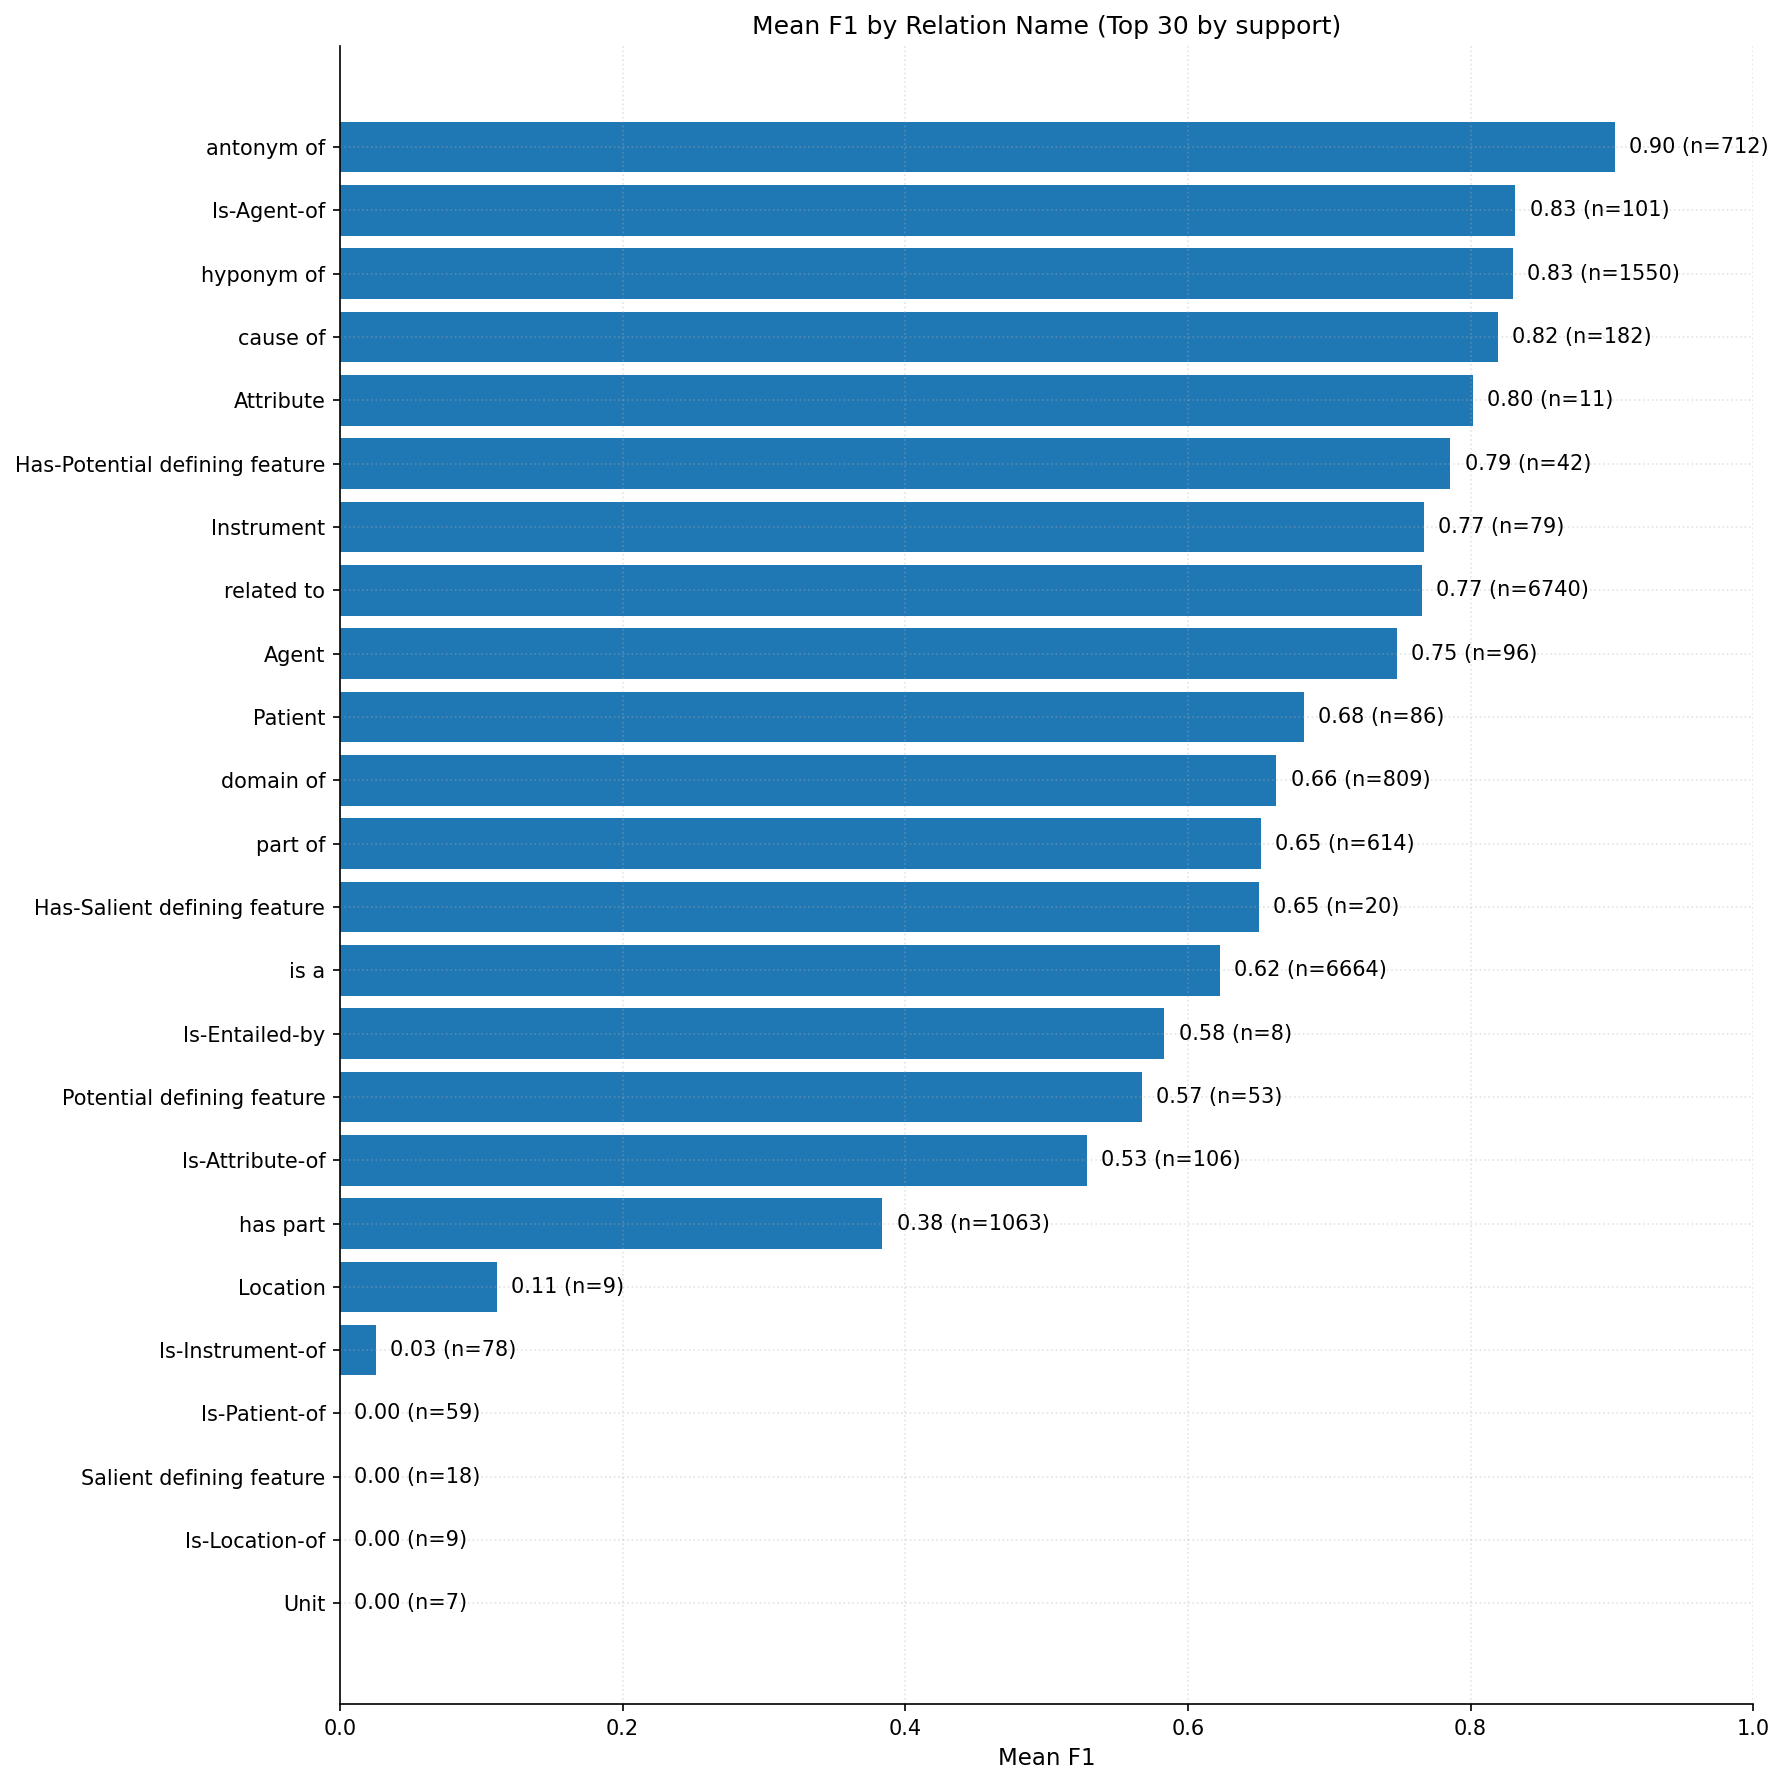

                          rel_name      mean  count
20                      antonym of  0.901857    712
8                      Is-Agent-of  0.831683    101
24                      hyponym of  0.829885   1550
21                        cause of  0.819048    182
2                        Attribute  0.801787     11
4   Has-Potential defining feature  0.785714     42
7                       Instrument  0.766667     79
27                      related to  0.765765   6740
1                            Agent  0.747917     96
15                         Patient  0.681748     86
22                       domain of  0.662546    809
26                         part of  0.651520    614
5     Has-Salient defining feature  0.650000     20
25                            is a  0.622299   6664
10                  Is-Entailed-by  0.583333      8
16      Potential defining feature  0.567296     53
9                  Is-Attribute-of  0.528302    106
23                        has part  0.383788   1063
14          

In [24]:


import pandas as pd, numpy as np, matplotlib.pyplot as plt

LOG_PATH   = "gpt_log_final_fixed.parquet"
CLEAN_FILE = "farsnet_facts_cleaned.parquet"

TOP_N_LONG = 30
MIN_COUNT  = 5

def normalize_f1(s):
    s = pd.to_numeric(s, errors="coerce")
    if s.dropna().mean() > 1: s = s/100.0
    return s.clip(0,1)

def to_phrase(name: str) -> str:
    s = str(name).strip().lower().replace("_"," ").replace("-"," ")
    if "hypernym" in s or s in {"isa","is a","is a relation"}: return "is a"
    if "hyponym"  in s or "subclass" in s:                      return "hyponym of"
    if "meronym"  in s or "part of" in s or "partof" in s:      return "part of"
    if "holonym"  in s or "has part" in s or "haspart" in s:    return "has part"
    if "antonym"  in s:                                         return "antonym of"
    if "domain"   in s:                                         return "domain of"
    if "member"   in s:                                         return "member of"
    if "instance" in s:                                         return "instance of"
    if "cause"    in s:                                         return "cause of"
    if "related"  in s or "assoc" in s:                         return "related to"
    return str(name)

df_map = pd.read_parquet(CLEAN_FILE, columns=["relation"])
rel2id = {rel:i for i,rel in enumerate(sorted(df_map["relation"].unique()))}
id2rel = {i: rel for rel, i in rel2id.items()}

df = pd.read_parquet(LOG_PATH)
assert "rel_id" in df.columns, "rel_id column is missing in the log."

df["f1"] = normalize_f1(df["f1"])
df = df.dropna(subset=["f1", "rel_id"]).copy()

df["rel_name_raw"] = df["rel_id"].map(id2rel).fillna("unknown")
df["rel_name"] = df["rel_name_raw"].map(to_phrase)

stats = (df.groupby("rel_name")["f1"]
           .agg(mean="mean", count="count")
           .reset_index())
stats = stats[stats["count"] >= MIN_COUNT]
stats = stats.sort_values(["count","mean"], ascending=[False, False]).head(TOP_N_LONG)
stats = stats.sort_values("mean", ascending=False)

plt.rcParams.update({"figure.dpi":150, "axes.spines.top":False, "axes.spines.right":False})
fig_h = max(4, 0.5 * len(stats))
plt.figure(figsize=(12, fig_h))
y = np.arange(len(stats))
plt.barh(y, stats["mean"])
plt.yticks(y, stats["rel_name"])
plt.gca().invert_yaxis()
plt.xlim(0, 1)
for yi, (m, n) in enumerate(zip(stats["mean"], stats["count"])):
    plt.text(m + 0.01, yi, f"{m:.2f} (n={n})", va="center", ha="left")
plt.xlabel("Mean F1")
plt.title(f"Mean F1 by Relation Name (Top {TOP_N_LONG} by support)")
plt.grid(axis="x", linestyle=":", alpha=0.35)
plt.tight_layout()
plt.savefig("f1_by_relation_name_topN.png", dpi=220)
plt.show()

print(stats.head(20))


C:\Users\elden lord\AppData\Local\Temp\ipykernel_25700\1370891546.py:149: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("RdYlGn")


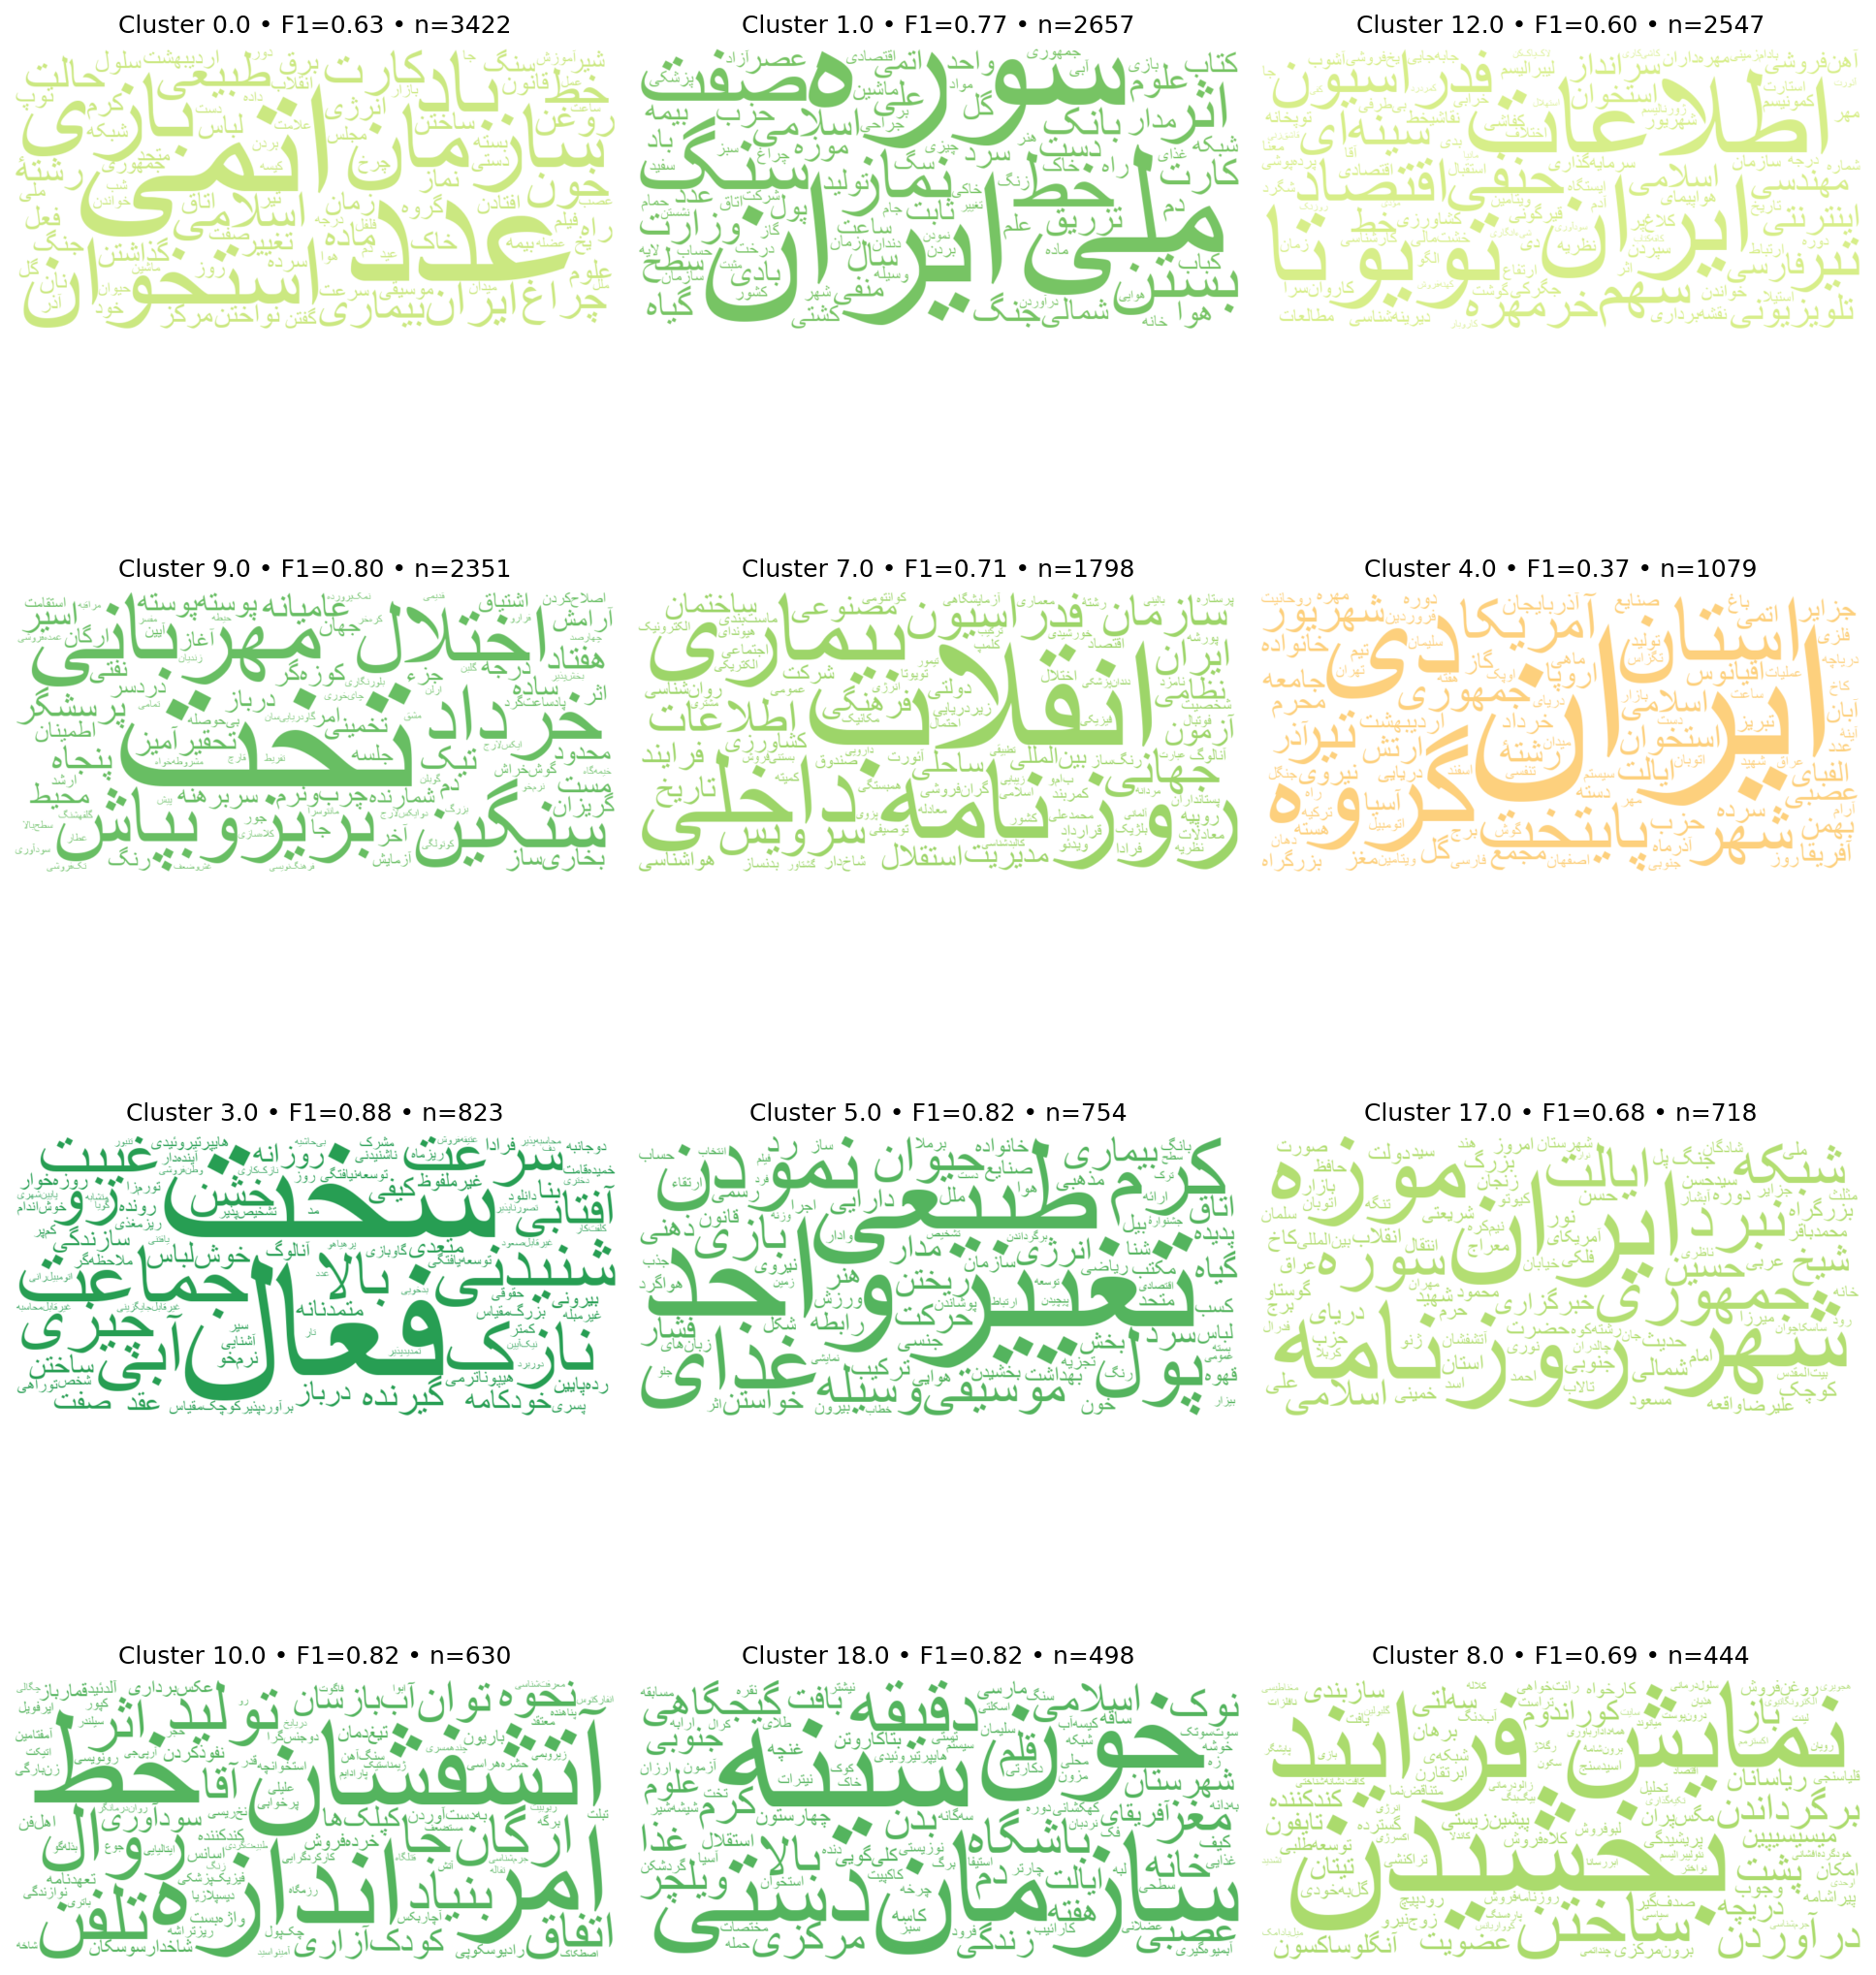

In [19]:

import os, re, math, ast
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from wordcloud import WordCloud
import arabic_reshaper
from bidi.algorithm import get_display
import matplotlib.cm as cm

LOG_PATH   = "gpt_log_final_fixed.parquet"
TOP_N      = 12
MIN_COUNT  = 8
WC_WIDTH   = 900
WC_HEIGHT  = 420

ARABIC_RANGE = r"[\u0600-\u06FF]"
PERSIAN_DIGITS = {ord(c): str(i) for i, c in enumerate("۰۱۲۳۴۵۶۷۸۹")}

STOPWORDS_FA = {
    "است","هست","نیست","بود","بودند","باش","باشد","باشند","شد","شده","شدن","شود",
    "می‌شود","می شود","میشود","کرد","کردن","کند","کن","کنید","می‌کند","می کند",
    "می‌کنید","می‌کنیم","می‌کنم","دار","دارد","دارند","داشت","داشتن","می‌باشد",
    "می باشد","باشد","به","در","از","را","و","یا","تا","برای","با","اما","اگر","هم",
    "که","این","آن","آنها","ایشان","وی","من","تو","او","ما","شما","هر","هیچ","همه",
    "یک","دو","سه","های","هایی","ای","ها","تر","ترین","می","می‌",
   "دادن","بودن","گرفتن","خوردن","بار","سر","رسیدن","ته","زدن","آوردن","آمدن","انداختن","آب","یافتن","زبان","رفتن","کسی","کشیدن","دستگاه","دانشگاه" ,"کار","روی"
}
STOPWORDS_EN = {
    "true","false","option","only","answer","english","persian","number","digit","space",
    "hypernym","hyponym","meronym","holonym","member","domain","instance","related","antonym","cause","part"
}

def norm_text(s: str) -> str:
    s = str(s).translate(PERSIAN_DIGITS)
    s = s.replace("ي","ی").replace("ك","ک").replace("ة","ه").replace("‏","")
    s = re.sub(r"[“”\"'«»\(\)\[\]{}<>:؛;!؟?]", " ", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s

def has_persian(s: str) -> bool:
    return bool(re.search(ARABIC_RANGE, s or ""))

def alias_first(text: str) -> str:
    text = str(text)
    return text.split("|", 1)[0].strip() if "|" in text else text

def tokenize(text: str):
    text = norm_text(text)
    parts = re.split(r"[,\u060C/\\\-]|(?:\sو\s)|(?:\sیا\s)|\s+", text)
    toks = []
    for p in parts:
        if not p:
            continue
        p = alias_first(p)
        n = norm_text(p)
        if not n or len(n) < 2 or not has_persian(n):
            continue
        if n in {norm_text(w) for w in STOPWORDS_FA}:
            continue
        if n.lower() in STOPWORDS_EN:
            continue
        toks.append(n)
    return toks

def shape_arabic(s: str) -> str:
    reshaped = arabic_reshaper.reshape(s)
    return get_display(reshaped)

def parse_listlike(val):
    if isinstance(val, list):
        return val
    if isinstance(val, str):
        try:
            return ast.literal_eval(val)
        except Exception:
            return [val]
    return [str(val)]

def pick_font_path():
    for p in [
        "/usr/share/fonts/truetype/noto/NotoNaskhArabic-Regular.ttf",
        "/usr/share/fonts/truetype/noto/NotoSansArabic-Regular.ttf",
        "/usr/share/fonts/truetype/noto/NotoKufiArabic-Regular.ttf",
        "C:\\Windows\\Fonts\\Vazirmatn-Regular.ttf",
        "C:\\Windows\\Fonts\\XB Zar.ttf",
        "C:\\Windows\\Fonts\\Arial.ttf",
        os.path.expanduser("~/Library/Fonts/Vazirmatn-Regular.ttf"),
        os.path.expanduser("~/Library/Fonts/NotoNaskhArabic-Regular.ttf"),
    ]:
        if os.path.exists(p):
            return p
    raise FileNotFoundError("Set `font_path` to a Persian/Arabic capable TTF.")

def normalize_f1(series):
    s = pd.to_numeric(series, errors="coerce")
    if s.dropna().mean() > 1:
        s = s/100.0
    return s.clip(0,1)

df = pd.read_parquet(LOG_PATH)
assert "cluster" in df.columns, "Missing 'cluster' column."

if "f1" in df.columns:
    df["f1"] = normalize_f1(df["f1"])
else:
    df["f1"] = np.nan

stats = (df.groupby("cluster")["f1"]
           .agg(mean="mean", count="count")
           .reset_index())
stats = stats[stats["count"] >= MIN_COUNT].sort_values(["count","mean"], ascending=[False,False])
top_clusters = stats.head(TOP_N).copy()

terms_map = {cid: Counter() for cid in top_clusters["cluster"].tolist()}

has_subject = "subject_words" in df.columns
has_objs    = "objs" in df.columns
has_answer  = "answer" in df.columns

for _, r in df[df["cluster"].isin(top_clusters["cluster"])].iterrows():
    cid = r["cluster"]

    if has_subject and pd.notna(r["subject_words"]):
        sw = alias_first(str(r["subject_words"]))
        terms_map[cid].update(tokenize(sw) * 5)

    if has_objs and pd.notna(r["objs"]):
        objs = parse_listlike(r["objs"])
        objs = [alias_first(o) for o in objs]
        terms_map[cid].update(tokenize(" ".join(map(str, objs))) * 3)

    elif has_answer and pd.notna(r["answer"]):
        ans = parse_listlike(r["answer"])
        ans = [alias_first(a) for a in ans]
        ans = [a for a in ans if has_persian(str(a))]
        if ans:
            terms_map[cid].update(tokenize(" ".join(map(str, ans))) * 2)

font_path = pick_font_path()
n = len(top_clusters)
ncols = 3 if n >= 7 else (2 if n >= 3 else 1)
nrows = math.ceil(n / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(13, 4.2*nrows), facecolor="white")
axes = np.array(axes).reshape(nrows, ncols)
for ax in axes.flat: ax.axis("off")

cmap = cm.get_cmap("RdYlGn")

for ax, (_, row) in zip(axes.flat, top_clusters.iterrows()):
    cid, mean, cnt = row["cluster"], float(row["mean"]), int(row["count"])
    freqs = terms_map.get(cid, Counter())

    shaped_freqs = {shape_arabic(k): v for k, v in freqs.most_common(120)}
    if not shaped_freqs:
        shaped_freqs = {shape_arabic(f"خوشه {cid}"): 1}

    wc = WordCloud(
        width=WC_WIDTH, height=WC_HEIGHT,
        background_color="white",
        prefer_horizontal=1.0,
        collocations=False,
        max_words=90,
        min_font_size=12,
        font_path=font_path,
    ).generate_from_frequencies(shaped_freqs)

    r,g,b,_ = cmap(np.clip(mean if not np.isnan(mean) else 0.5, 0, 1))
    rgb255 = (int(255*r), int(255*g), int(255*b))
    wc.recolor(color_func=lambda *a, **k: f"rgb({rgb255[0]}, {rgb255[1]}, {rgb255[2]})")

    ax.imshow(wc, interpolation="bilinear")
    title_f1 = f"{mean:.2f}" if not np.isnan(mean) else "NA"
    ax.set_title(f"Cluster {cid} • F1={title_f1} • n={cnt}", fontsize=12, pad=8)


plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig("cluster_wordclouds_clustered.png", dpi=240)
plt.show()


,timestamp,qid,sid,rel_id,response,tp,fp,fn,prec,recall,f1,user_prompt,answer,subject_words,cluster,cluster_rank,alpha,beta,theta,q_format
0,2025-08-13T11:27:14.982168+00:00,1,1.0,2,4,1.0,0.0,0.0,1.000000,1.0,1.000000,«کدام گزینه‌ها Antonym «بیرونی|خارجی|روکار|برو...,['4'],بیرونی|خارجی|روکار|برونی,3,8.043461,1,2,0.333333,select_all_mcq
1,2025-08-13T11:27:14.982168+00:00,94267,38414.0,10,False,1.0,0.0,0.0,1.000000,1.0,1.000000,«آیا «خود را به نادانی زدن|خود را به جهالت زدن...,['False'],خود را به نادانی زدن|خود را به جهالت زدن|خود ر...,0,1.154475,1,2,0.333333,true_false
2,2025-08-13T11:27:14.982168+00:00,94255,38410.0,32,"2,3",2.0,0.0,0.0,1.000000,1.0,1.000000,«کدام گزینه‌ها Related-to «ارلن|ارلن‌مایر|بالن...,"['3', '2']",ارلن|ارلن‌مایر|بالن ارلن‌مایر,9,9.066424,1,2,0.333333,select_all_mcq
3,2025-08-13T11:27:14.982168+00:00,94252,38409.0,35,آزمایشگاه,0.0,1.0,1.0,0.000000,0.0,0.000000,«1 مورد از «Substance holonym» برای «لوله آزما...,['آبگینه|زجاج|شیشه|زجاجه'],لوله آزمایش,11,3.582295,2,1,0.666667,short_list
4,2025-08-13T11:27:14.982168+00:00,94244,38407.0,32,4,1.0,0.0,0.0,1.000000,1.0,1.000000,«کدام گزینه‌ها Related-to «محجور» هستند؟»\n1) ...,['4'],محجور,1,6.339501,1,2,0.333333,select_all_mcq
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19123,2025-08-13T11:27:14.982168+00:00,49177,22840.0,10,False,0.0,1.0,1.0,0.000000,0.0,0.000000,«آیا «توضیح‌المسایل|رساله|رساله عملیه|رساله تو...,['True'],توضیح‌المسایل|رساله|رساله عملیه|رساله توضیح‌ال...,12,1.219283,2,1,0.666667,true_false
19124,2025-08-13T11:27:14.982168+00:00,49175,22839.0,32,"1,3,4,5,6,8,9,10,11",8.0,1.0,2.0,0.888889,0.8,0.842105,«کدام گزینه‌ها Related-to «بازداشتگاه|توقیفگاه...,"['8', '9', '6', '1', '5', '12', '10', '11', '4...",بازداشتگاه|توقیفگاه,9,9.066424,1,2,0.333333,select_all_mcq
19125,2025-08-13T11:27:14.982168+00:00,49165,22837.0,32,1,1.0,0.0,0.0,1.000000,1.0,1.000000,«کدام گزینه‌ها Related-to «تناسل» هستند؟»\n1) ...,['1'],تناسل,1,6.339501,1,2,0.333333,select_all_mcq
19126,2025-08-13T11:27:14.982168+00:00,49155,22833.0,32,4,1.0,0.0,0.0,1.000000,1.0,1.000000,«کدام گزینه‌ها Related-to «مضحکی|جلفی|لودگی|سب...,['4'],مضحکی|جلفی|لودگی|سبک‌سری|جلف‌بازی|زنندگی|جلافت...,9,9.066424,1,2,0.333333,select_all_mcq
